In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../artifacts/raw.csv')

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.shape

(2772, 7)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(1337, 7)

In [8]:
Q1=df['charges'].quantile(0.25)
Q3=df['charges'].quantile(0.75)
IQR=Q3 - Q1

In [9]:
print("Quentile Q1 :- ", Q1)
print("Quentile Q3 :- ", Q3)
print("IQR :- ", IQR)

Quentile Q1 :-  4746.344
Quentile Q3 :-  16657.71745
IQR :-  11911.37345


In [14]:
new_df=df[(df['charges'] >= Q1 -1.5 * IQR ) & (df['charges'] <= Q3 + 1.5 * IQR)]

In [15]:
new_df.shape

(1198, 7)

<Axes: xlabel='charges'>

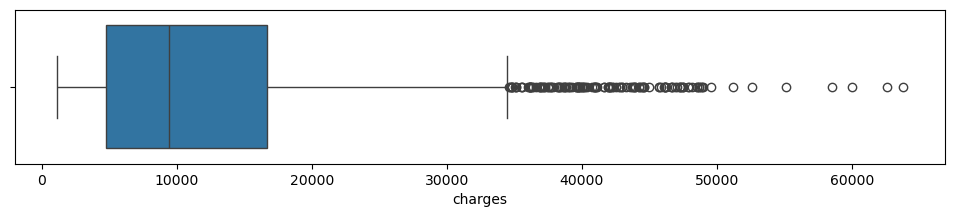

In [16]:
plt.figure(figsize=(12,2))
sns.boxplot(data=df, x=df['charges'])

<Axes: xlabel='charges'>

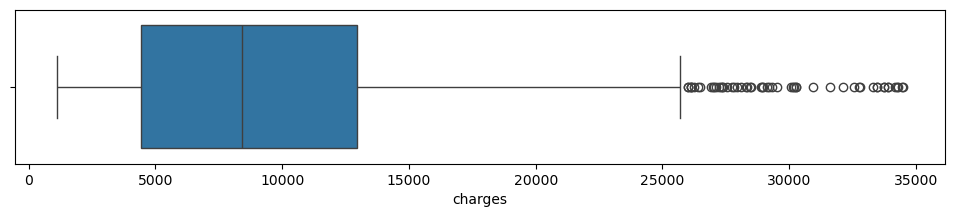

In [17]:
plt.figure(figsize=(12,2))
sns.boxplot(data=new_df, x=new_df['charges'])

In [18]:
new_df=pd.get_dummies(new_df, drop_first=True, dtype=int)

In [19]:
new_df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,1,0,0
1334,18,31.920,0,2205.98080,0,0,0,0,0
1335,18,36.850,0,1629.83350,0,0,0,1,0
1336,21,25.800,0,2007.94500,0,0,0,0,1


In [20]:
new_df.to_csv('../artifacts/clean_data.csv')